## [0] INSTALACION DE LIBRERIAS UTILIZADAS

In [34]:
import sys
!{sys.executable} -m pip install opencv-python

import sys
!{sys.executable} -m pip install scikit-learn

import sys
!{sys.executable} -m pip install tensorflow

import sys
!{sys.executable} -m pip install matplotlib

!pip install minisom


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## [1] LECTURA DE LA DATA DEL PACIENTE PN00

Solo se considera 18 canales para la data. Se tiene 5 episodios, de los cuales se descarta el episodio 3. Se muestra la configuracion de los restantes episodios para la red neuronal.

- Episodio 1 y 2: Entrenamiento
- Episodio 4: Prueba
- Episodio 5: Revaluacion

In [3]:
# para modificar la data a los canales que requerimos

import mne
import os
import numpy as np

# RUTA DE LOS ARCHIVOS EDF
#edf_dir = r"D:\CICLO 2025-2 UNI\PROGRAMACION_PARALELA\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00"
edf_dir =r"D:\PROGRAMACION_PARALELA_CODIGO\TRABAJO INVESTIGACION PARALELA\Codigo\data\PN00"

# CANALES REPRESENTATIVOS (18 CANALES EEG CONFIRMADOS)
REP_CHANNELS = [
    "T3", "T4", "T5", "T6",
    "Fp1", "Fp2", "F3", "F4", "F7", "F8",
    "C3", "C4", "Cz",
    "P3", "P4", "Pz",
    "O1", "O2"
]

# FUNCIÓN AUXILIAR: NOMBRE BASE DEL CANAL
def base_name(ch):
    # Convierte "EEG Fp1" -> "Fp1"
    return ch.replace("EEG ", "")

# ---------- ENTRENAMIENTO ----------
train_files = ["PN00-1.edf", "PN00-2.edf"]

raws_train = [
    mne.io.read_raw_edf(
        os.path.join(edf_dir, f),
        preload=True,
        verbose="error"
    )
    for f in train_files
]

raw_train = mne.concatenate_raws(raws_train)

# --- Selección directa por nombre base (forma correcta aquí) ---
available_train = [
    ch for ch in raw_train.ch_names
    if base_name(ch) in REP_CHANNELS
]

# Forzar orden fijo (CRÍTICO para RN)
available_train = [
    f"EEG {ch}" for ch in REP_CHANNELS
    if f"EEG {ch}" in available_train
]

raw_train.pick(available_train)

print("Canales entrenamiento:")
print(raw_train.ch_names)
print("raw_train shape:", raw_train.get_data().shape)
# ==> (18, N_train)


# PRUEBA 
test_files = ["PN00-4.edf"]

raws_test = [
    mne.io.read_raw_edf(
        os.path.join(edf_dir, f),
        preload=True,
        verbose="error"
    )
    for f in test_files
]

raw_test = mne.concatenate_raws(raws_test)

available_test = [
    ch for ch in raw_test.ch_names
    if base_name(ch) in REP_CHANNELS
]

available_test = [
    f"EEG {ch}" for ch in REP_CHANNELS
    if f"EEG {ch}" in available_test
]

raw_test.pick(available_test)

print("\nCanales prueba:")
print(raw_test.ch_names)
print("raw_test shape:", raw_test.get_data().shape)
# ==> (18, N_test)


# REEVALUACION
retest_files = ["PN00-5.edf"]

raws_retest = [
    mne.io.read_raw_edf(
        os.path.join(edf_dir, f),
        preload=True,
        verbose="error"
    )
    for f in retest_files
]

raw_retest = mne.concatenate_raws(raws_retest)

available_retest = [
    ch for ch in raw_retest.ch_names
    if base_name(ch) in REP_CHANNELS
]

available_retest = [
    f"EEG {ch}" for ch in REP_CHANNELS
    if f"EEG {ch}" in available_retest
]

raw_retest.pick(available_retest)

X_retest = raw_retest.get_data()

print("\nCanales reevaluación:")
print(raw_retest.ch_names)
print("raw_retest shape:", X_retest.shape)
# ==> (18, N_retest)


Canales entrenamiento:
['EEG T3', 'EEG T4', 'EEG T5', 'EEG T6', 'EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG C3', 'EEG C4', 'EEG Cz', 'EEG P3', 'EEG P4', 'EEG Pz', 'EEG O1', 'EEG O2']
raw_train shape: (18, 2522624)

Canales prueba:
['EEG T3', 'EEG T4', 'EEG T5', 'EEG T6', 'EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG C3', 'EEG C4', 'EEG Cz', 'EEG P3', 'EEG P4', 'EEG Pz', 'EEG O1', 'EEG O2']
raw_test shape: (18, 1076224)

Canales reevaluación:
['EEG T3', 'EEG T4', 'EEG T5', 'EEG T6', 'EEG Fp1', 'EEG Fp2', 'EEG F3', 'EEG F4', 'EEG F7', 'EEG F8', 'EEG C3', 'EEG C4', 'EEG Cz', 'EEG P3', 'EEG P4', 'EEG Pz', 'EEG O1', 'EEG O2']
raw_retest shape: (18, 1097216)


In [4]:
# ============================================================
# Para las variable de entrenamiento, ver la union, tiempos absolutos
# de los episodios, inicio de episodios.
import numpy as np

# FRECUENCIA DE MUESTREO
sfreq = int(raw_train.info["sfreq"])     # 512 Hz

# DATA DE ENTRENAMIENTO
datatrain = raw_train.get_data()         # shape = (18, N_samples_train)
n_samples_train = datatrain.shape[1]
Ntrain = n_samples_train // sfreq        # duración total (s)

# DATA DE PRUEBA
datatest = raw_test.get_data()            # shape = (18, N_samples_test)
n_samples_test = datatest.shape[1]
Ntest = n_samples_test // sfreq

# INFORMACIÓN DE FILTRADO
lowpass = raw_train.info["lowpass"]

# CANALES
ch_names = raw_train.ch_names
n_chan = len(ch_names)                    # DEBE ser 18

# ÍNDICES DE CANALES (ORDEN REAL Y FIJO)
T3, T4, T5, T6, \
Fp1, Fp2, F3, F4, F7, F8, \
C3, C4, Cz, \
P3, P4, Pz, \
O1, O2 = range(18)

# EVENTOS DE CRISIS (TIEMPOS REALES, PN00-1 y PN00-2)
# --- PN00-1.edf ---
# Inicio registro : 19:39:33
# Inicio crisis   : 19:58:36  -> 1143 s
# Fin crisis      : 19:59:46  -> 1213 s
seizure1_start = 1143
seizure1_end   = 1213

# --- PN00-2.edf ---
# Inicio registro : 02:18:17
# Inicio crisis   : 02:38:37  -> 1220 s
# Fin crisis      : 02:39:31  -> 1274 s

# Duración PN00-1 en segundos (para corrimiento)
dur_PN00_1_sec = raws_train[0].n_times // sfreq

seizure2_start = dur_PN00_1_sec + 1220
seizure2_end   = dur_PN00_1_sec + 1274

# VECTORES DE EVENTOS (INICIO DE CRISIS)
secondeventscrisis = np.array([
    seizure1_start,
    seizure2_start
])


In [5]:
n_time_samps = raw_train.n_times
time_secs = raw_train.times
ch_names = raw_train.ch_names
n_chan = len(ch_names)  # note: there is no raw.n_channels attribute
print(
    f"the (cropped) sample data object has {n_time_samps} time samples and "
    f"{n_chan} channels."
)
print(f"The last time sample is at {time_secs[-1]} seconds.")
print("The first few channel names are {}.".format(", ".join(ch_names[:3])))
print()  # insert a blank line in the output

# some examples of raw.info:
print("bad channels:", raw_train.info["bads"])  # chs marked "bad" during acquisition
print(raw_train.info["sfreq"], "Hz")  # sampling frequency
print(raw_train.info["description"], "\n")  # miscellaneous acquisition info

print(raw_train.info)

the (cropped) sample data object has 2522624 time samples and 18 channels.
The last time sample is at 4926.998046875 seconds.
The first few channel names are EEG T3, EEG T4, EEG T5.

bad channels: []
512.0 Hz
None 

<Info | 8 non-empty values
 bads: []
 ch_names: EEG T3, EEG T4, EEG T5, EEG T6, EEG Fp1, EEG Fp2, EEG F3, EEG ...
 chs: 18 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 256.0 Hz
 meas_date: 2016-01-01 19:39:33 UTC
 nchan: 18
 projs: []
 sfreq: 512.0 Hz
 subject_info: <subject_info | his_id: >
>


In [ ]:
# Rutina de preprocesamiento para EEG que genera ventanas temporales de 1 segundo y asigna etiquetas interictal (0), preictal (2) e ictal (1), considerando duración de crisis, frecuencia de muestreo
# y balance de clases mediante oversampling.

import numpy as np

def patterndandtarget(F, S, tp, sfreq, ad_1=0, ad_2=0, N=None):
    """
    Genera ventanas EEG (segmentos de 1 segundo) y asigna clases:
      0 -> normal
      1 -> ictal (durante la crisis)
      2 -> preictal (tp segundos antes del inicio de crisis)

    Parámetros
    ----------
    F : np.ndarray
        Señal EEG. Puede ser:
          - shape (n_samples, n_chan)  (recomendado)
          - shape (n_chan, n_samples)  (también soportado)
    S : list / np.ndarray
        Crisis como:
          - [start1, end1, start2, end2, ...]  (segundos relativos)
          - [(start1,end1), (start2,end2), ...]
    tp : int
        Cuántos segundos ANTES de cada inicio se etiquetan como preictal (clase 2).
    sfreq : int
        Frecuencia de muestreo (ej. 512).
    ad_1 : int
        Aumento (oversampling) de clase 1: duplica ad_1 veces cada ventana ictal.
    ad_2 : int
        Aumento (oversampling) de clase 2: duplica ad_2 veces cada ventana preictal.
    N : int | None
        Número de segmentos (segundos) a generar. Si None, se calcula desde F.

    Retorna
    -------
    X : np.ndarray
        Ventanas de 1 segundo.
    y : np.ndarray
        Etiquetas por ventana.
    """


    # Normalizar forma de F a (n_samples, n_chan)
    F = np.asarray(F)
    if F.ndim == 1:
        # Caso 1D: (n_samples,) -> lo tratamos como 1 canal
        F = F[:, None]
    elif F.shape[0] < F.shape[1] and F.shape[0] <= 64:
        # Heurística común: si F es (n_chan, n_samples), lo transponemos
        # (esto evita errores si te llega en formato MNE: (n_chan, n_samples))
        # OJO: si ya está en (n_samples, n_chan), no se transpone.
        # Para tu caso, raw.get_data() da (n_chan, n_samples), así que esto ayuda.
        F = F.T

    n_samples = F.shape[0]


    # Número de segmentos (1 segundo)
    if N is None:
        N = n_samples // sfreq  # segundos completos


    # Parsear S a lista de intervalos [(start,end), ...]
    S = np.asarray(S, dtype=int)

    intervals = []
    if S.ndim == 2 and S.shape[1] == 2:
        # [(start,end), ...]
        intervals = [(int(a), int(b)) for a, b in S]
    else:
        # [start1,end1,start2,end2,...]
        if len(S) % 2 != 0:
            raise ValueError("S debe tener longitud par: [start1,end1,start2,end2,...]")
        for i in range(0, len(S), 2):
            a = int(S[i]); b = int(S[i+1])
            intervals.append((a, b))

    # Validar/normalizar intervalos (por si vienen desordenados)
    intervals = [(min(a, b), max(a, b)) for a, b in intervals]


    # Conjuntos de segundos ictales y preictales
    ictal_secs = set()
    preictal_secs = set()

    for (start, end) in intervals:
        # Ictal: incluye TODO el intervalo [start, end]
        for t in range(max(0, start), max(0, end) + 1):
            ictal_secs.add(t)

        # Preictal: tp segundos antes del inicio: start-tp ... start-1
        for t in range(max(0, start - tp), max(0, start)):
            preictal_secs.add(t)

    # Regla: si un segundo cae en ictal, gana clase 1 (prioridad)
    preictal_secs = preictal_secs - ictal_secs

    # Construir ventanas + etiquetas
    X = []
    y = []

    for seg in range(N):
        a = seg * sfreq
        b = (seg + 1) * sfreq
        if b > n_samples:
            break  # no hay segundo completo

        window = F[a:b, :]  # shape (sfreq, n_chan)

        # Etiquetado por prioridad: 1 > 2 > 0
        if seg in ictal_secs:
            label = 1
            X.append(window); y.append(label)
            for _ in range(ad_1):
                X.append(window); y.append(label)

        elif seg in preictal_secs:
            label = 2
            X.append(window); y.append(label)
            for _ in range(ad_2):
                X.append(window); y.append(label)

        else:
            label = 0
            X.append(window); y.append(label)

    return np.array(X), np.array(y)


El módulo Gabor transforma cada ventana EEG de 1 segundo en una representación tiempo–frecuencia mediante un banco de filtros orientados, preservando las etiquetas interictal, preictal e ictal generadas previamente.

In [7]:
# representatividad de las frecuencias en cada segundo, basada en el filtro de Gabor
import cv2
def apply_filter(img, filters):
# This general function is designed to apply filters to our image

    # First create a numpy array the same size as our input image
    newimage = np.zeros_like(img)

    # Starting with a blank image, we loop through the images and apply our Gabor Filter
    # On each iteration, we take the highest value (super impose), until we have the max value across all filters
    # The final image is returned
    depth = -1 # remain depth same as original image

    for kern in filters:  # Loop through the kernels in our GaborFilter
        image_filter = cv2.filter2D(img, depth, kern)  #Apply filter to image

        # Using Numpy.maximum to compare our filter and cumulative image, taking the higher value (max)
        np.maximum(newimage, image_filter, newimage)
    return newimage

def create_gaborfilter():
    # This function is designed to produce a set of GaborFilters
    # an even distribution of theta values equally distributed amongst pi rad / 180 degree

    filters = []
    num_filters = 16
    ksize = 35  # The local area to evaluate
    sigma = 3.0  # Larger Values produce more edges
    lambd = 10.0
    gamma = 0.5
    psi = 0  # Offset value - lower generates cleaner results
    for theta in np.arange(0, np.pi, np.pi / num_filters):  # Theta is the orientation for edge detection
        kern = cv2.getGaborKernel((ksize, ksize), sigma, theta, lambd, gamma, psi, ktype=cv2.CV_64F)
        kern /= 1.0 * kern.sum()  # Brightness normalization
        filters.append(kern)
    return filters

In [8]:
# segmenta EEG en ventanas de 1seg, aplica filtro de Gabor y etiqueta
def patterndandtarget2d(data2d,S,tp,ad_1=0,ad_2=0):
  sfreq = 512 
  filters = create_gaborfilter()
  sucesos = np.array(S)
  tamano_previo = tp
  segundos_antes = []
  for s in sucesos:
    for i in range(tamano_previo):
      segundos_antes.append(s-i-1)
  segundos_antes = np.array(segundos_antes)
  x_input = []
  y_target = []
  for seg in range(int(max(data2d[0,:].shape)/sfreq)-1):
    x_input.append(apply_filter(data2d[:,seg*sfreq:(seg+1)*sfreq], filters))
    if seg in segundos_antes:
      y_target.append(2)
      for i in range(ad_2):
        x_input.append(apply_filter(data2d[:,seg*sfreq:(seg+1)*sfreq], filters))
        y_target.append(2)
    elif seg in sucesos:
      y_target.append(1)
      for i in range(ad_1):
        x_input.append(apply_filter(data2d[:,seg*sfreq:(seg+1)*sfreq], filters))
        y_target.append(1)
    else:
      y_target.append(0)
  return np.array(x_input),np.array(y_target)

In [9]:
# 80% se dividira para entrenamiento y el 20% para pruebas.

from sklearn.model_selection import train_test_split
aditional_replicate_1 = 500
aditional_replicate_2 = 500
sfreq = 500
data2d = datatrain.copy()
time_preview = 5
x_train2d,y_train2d = patterndandtarget2d(data2d,secondeventscrisis,time_preview,aditional_replicate_1,aditional_replicate_2)

print(x_train2d.shape)
print(y_train2d.shape)

x_train2d, x_test2d, y_train2d, y_test2d = train_test_split(x_train2d,y_train2d,
                                                    test_size = 0.2,
                                                    random_state = 1)
print("from train")
print(x_train2d.shape)
print(y_train2d.shape)
print("from test")
print(x_test2d.shape)
print(y_test2d.shape)

(7926, 18, 512)
(7926,)
from train
(6340, 18, 512)
(6340,)
from test
(1586, 18, 512)
(1586,)


## [2] FULLY CONNECTED NEURONAL NETWORK

In [19]:
import tensorflow as tf

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten())

model.add(tf.keras.layers.Dense(
    128, activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
))

model.add(tf.keras.layers.Dense(
    128, activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
))

model.add(tf.keras.layers.Dense(
    128, activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
))

model.add(tf.keras.layers.Dense(
    3, activation='softmax',
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train2d, y_train2d,
    epochs=20,
    validation_data=(x_test2d, y_test2d)
)

test_loss, test_acc = model.evaluate(x_test2d, y_test2d)
print('\nTest accuracy:', test_acc)


Epoch 1/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6180 - loss: 0.8673 - val_accuracy: 0.6274 - val_loss: 0.8523
Epoch 2/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6191 - loss: 0.8404 - val_accuracy: 0.6274 - val_loss: 0.8421
Epoch 3/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6191 - loss: 0.8392 - val_accuracy: 0.6274 - val_loss: 0.8448
Epoch 4/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6191 - loss: 0.8391 - val_accuracy: 0.6274 - val_loss: 0.8420
Epoch 5/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6191 - loss: 0.8339 - val_accuracy: 0.6274 - val_loss: 0.8352
Epoch 6/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6191 - loss: 0.8201 - val_accuracy: 0.6274 - val_loss: 0.8137
Epoch 7/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6964 - loss: 0.6804 - val_accuracy: 0.6198 - val_loss: 0.6089
Epoch 8/20
199/199 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8811 - loss: 0.4665 - val_accu

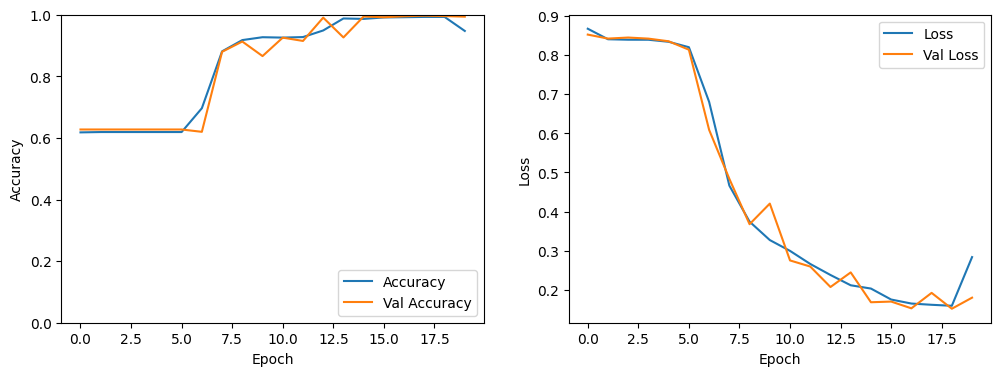

In [20]:
# dibujo de la resultado de la precision
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.show()

En esta parte se valida el modelo con el modelo predictivo. Se hace la matrix de confusion para ver el accuracy

Funcion de ploteo de matriz de confusion

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_pretty(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 6))

    # Heatmap
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)

    # Barra de color
    cbar = plt.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Count", rotation=270, labelpad=15)

    # Ejes y etiquetas
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted",
        ylabel="Expected",
        title="Confusion Matrix"
    )

    # Etiquetas arriba (como tu imagen)
    ax.tick_params(
        top=True,
        bottom=False,
        labeltop=True,
        labelbottom=False
    )

    # Valores dentro de cada celda
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, f"{cm[i, j]}",
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.tight_layout()
    plt.show()


Predicion del modelo para los datos de test2d

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[985   0  10]
 [  0 110   0]
 [  0   0 481]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       995
           1       1.00      1.00      1.00       110
           2       0.98      1.00      0.99       481

    accuracy                           0.99      1586
   macro avg       0.99      1.00      0.99      1586
weighted avg       0.99      0.99      0.99      1586



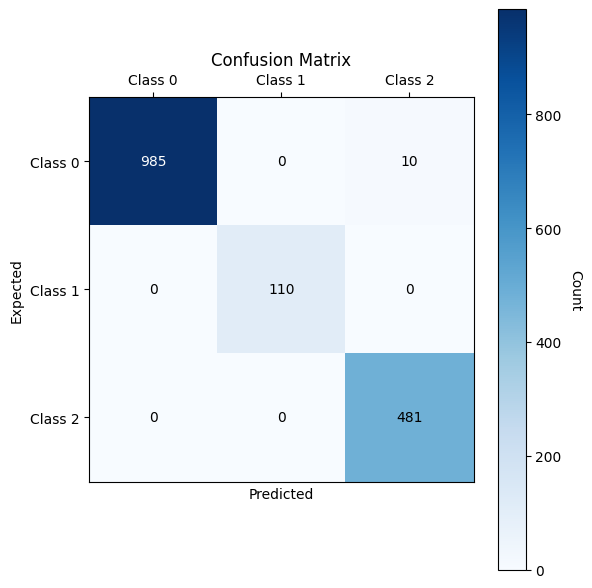

In [ ]:

from sklearn.metrics import confusion_matrix, classification_report

# PREDICCIÓN DEL MODELO (FORMA CORRECTA)
salida = model.predict(x_test2d)

# Clase predicha = argmax
y_simulado = np.argmax(salida, axis=1)


# DIBUJAR MATRIZ DE CONFUSIÓN
class_names = ["Class 0", "Class 1", "Class 2"]

print(confusion_matrix(y_test2d, y_simulado))
print(classification_report(y_test2d, y_simulado))

plot_confusion_matrix_pretty(
    y_true=y_test2d,
    y_pred=y_simulado,
    class_names=class_names
)

Predicion del modelo para los datos de traint2d

199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[3871    6   48]
 [   0  391    0]
 [   0    0 2024]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3925
           1       0.98      1.00      0.99       391
           2       0.98      1.00      0.99      2024

    accuracy                           0.99      6340
   macro avg       0.99      1.00      0.99      6340
weighted avg       0.99      0.99      0.99      6340



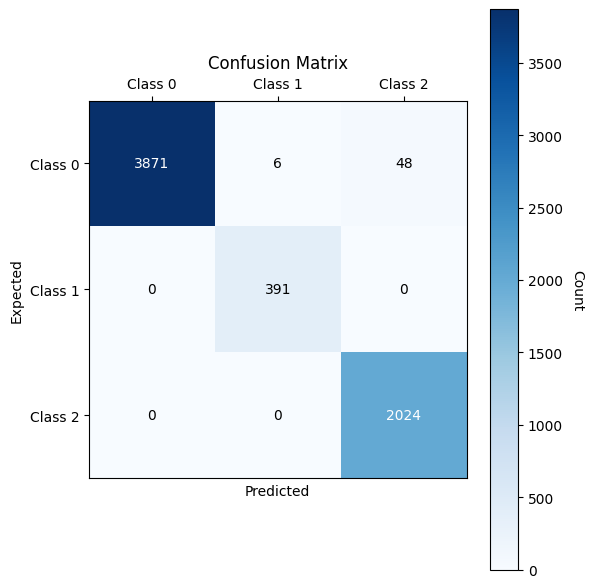

In [33]:
# PREDICCIÓN DEL MODELO 
# Salida 
salida = model.predict(x_train2d)

# Clase predicha = argmax
y_simulado = np.argmax(salida, axis=1)

# DIBUJAR MATRIZ DE CONFUSIÓN
class_names = ["Class 0", "Class 1", "Class 2"]

print(confusion_matrix(y_train2d, y_simulado))
print(classification_report(y_train2d, y_simulado))

plot_confusion_matrix_pretty(
    y_true=y_train2d,
    y_pred=y_simulado,
    class_names=class_names
)

## [3] RED NEURONAL SOM

Pasar los datos de entrada de bidimensionales a vectoriales, para que puedan aplicarse como patrones de entrada al modelo SOM

Red SOM con librerias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from minisom import MiniSom
from collections import defaultdict, Counter
from sklearn.preprocessing import StandardScaler

# Flatten
x_train1d = x_train2d.reshape(x_train2d.shape[0], -1)
x_test1d  = x_test2d.reshape(x_test2d.shape[0], -1)

# Normalización (OBLIGATORIA para SOM)
scaler = StandardScaler()
x_train1d = scaler.fit_transform(x_train1d)
x_test1d  = scaler.transform(x_test1d)

max_iter = 4000
alpha_max = 0.5
dimension = np.array([10, 20, 30], dtype=int)

resultados = np.zeros(len(dimension))


In [44]:
for j, d in enumerate(dimension):

    print(f"Entrenando SOM {d}x{d}")

    # Definir SOM
    som = MiniSom(
        x=d, y=d,
        input_len=x_train1d.shape[1],
        sigma=1.0,
        learning_rate=alpha_max,
        activation_distance='euclidean',
        topology='hexagonal',
        neighborhood_function='gaussian',
        random_seed=42
    )

    # Inicialización y entrenamiento (SOLO con train)
    som.random_weights_init(x_train1d)
    som.train_random(x_train1d, max_iter)

    # ===== ETIQUETADO POR MAYORÍA (CORRECTO) =====
    label_map = defaultdict(list)

    for x, y in zip(x_train1d, y_train2d):
        label_map[som.winner(x)].append(y)

    # Mapa final de etiquetas
    M = np.full((d, d), -1, dtype=int)

    for pos, labels in label_map.items():
        M[pos] = Counter(labels).most_common(1)[0][0]

    # Clase mayoritaria global (backup)
    clase_global = Counter(y_train2d).most_common(1)[0][0]

    # ===== PREDICCIÓN EN TEST =====
    y_pred = []
    for x in x_test1d:
        pos = som.winner(x)
        if M[pos] != -1:
            y_pred.append(M[pos])
        else:
            y_pred.append(clase_global)

    y_pred = np.array(y_pred)

    # Accuracy
    resultados[j] = np.mean(y_pred == y_test2d)

    print(f"Accuracy SOM {d}x{d}: {resultados[j]:.4f}")


Entrenando SOM 10x10
Accuracy SOM 10x10: 1.0000
Entrenando SOM 20x20
Accuracy SOM 20x20: 1.0000
Entrenando SOM 30x30
Accuracy SOM 30x30: 1.0000


Mejor dimensión SOM: 10 x 10
[[3917    2    6]
 [   0  391    0]
 [   0    0 2024]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3925
           1       0.99      1.00      1.00       391
           2       1.00      1.00      1.00      2024

    accuracy                           1.00      6340
   macro avg       1.00      1.00      1.00      6340
weighted avg       1.00      1.00      1.00      6340



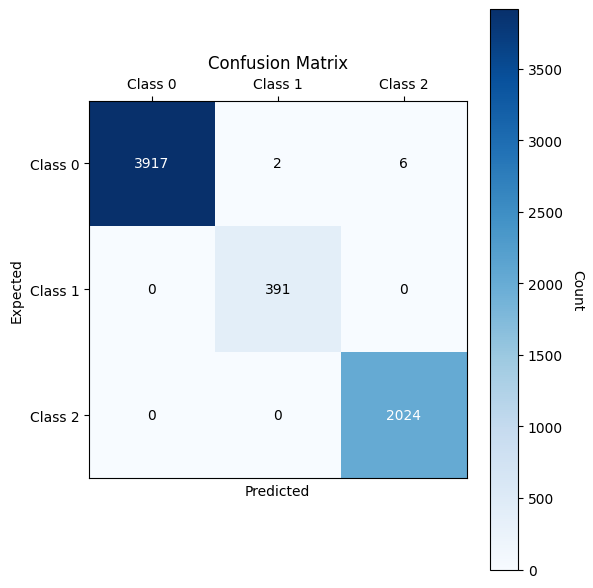

In [47]:
import numpy as np
from minisom import MiniSom
from collections import defaultdict, Counter
from sklearn.metrics import confusion_matrix, classification_report

# ===============================
# 1. Seleccionar mejor dimensión
# ===============================
d = dimension[np.argmax(resultados)]
print(f"Mejor dimensión SOM: {d} x {d}")

# ===============================
# 2. Entrenar SOM con train
# ===============================
max_iter = 5000
alpha_max = 0.5

som = MiniSom(
    x=d, y=d,
    input_len=x_train1d.shape[1],
    sigma=1.0,
    learning_rate=alpha_max,
    activation_distance='euclidean',
    topology='hexagonal',
    neighborhood_function='gaussian',
    random_seed=42
)

som.random_weights_init(x_train1d)
som.train_random(x_train1d, max_iter)

# ===============================
# 3. Etiquetado por mayoría
# ===============================
label_map = defaultdict(list)

for x, y in zip(x_train1d, y_train2d):
    label_map[som.winner(x)].append(y)

M = np.full((d, d), -1, dtype=int)
for pos, labels in label_map.items():
    M[pos] = Counter(labels).most_common(1)[0][0]

# Clase global (por si acaso)
clase_global = Counter(y_train2d).most_common(1)[0][0]

# ===============================
# 4. Evaluación en ENTRENAMIENTO
# ===============================
y_pred_train = []

for x in x_train1d:
    pos = som.winner(x)
    if M[pos] != -1:
        y_pred_train.append(M[pos])
    else:
        y_pred_train.append(clase_global)

y_pred_train = np.array(y_pred_train)

# ===============================
# 5. Métricas
# ===============================
class_names = ["Class 0", "Class 1", "Class 2"]

print(confusion_matrix(y_train2d, y_pred_train))
print(classification_report(y_train2d, y_pred_train))

plot_confusion_matrix_pretty(
    y_true=y_train2d,
    y_pred=y_pred_train,
    class_names=class_names
)


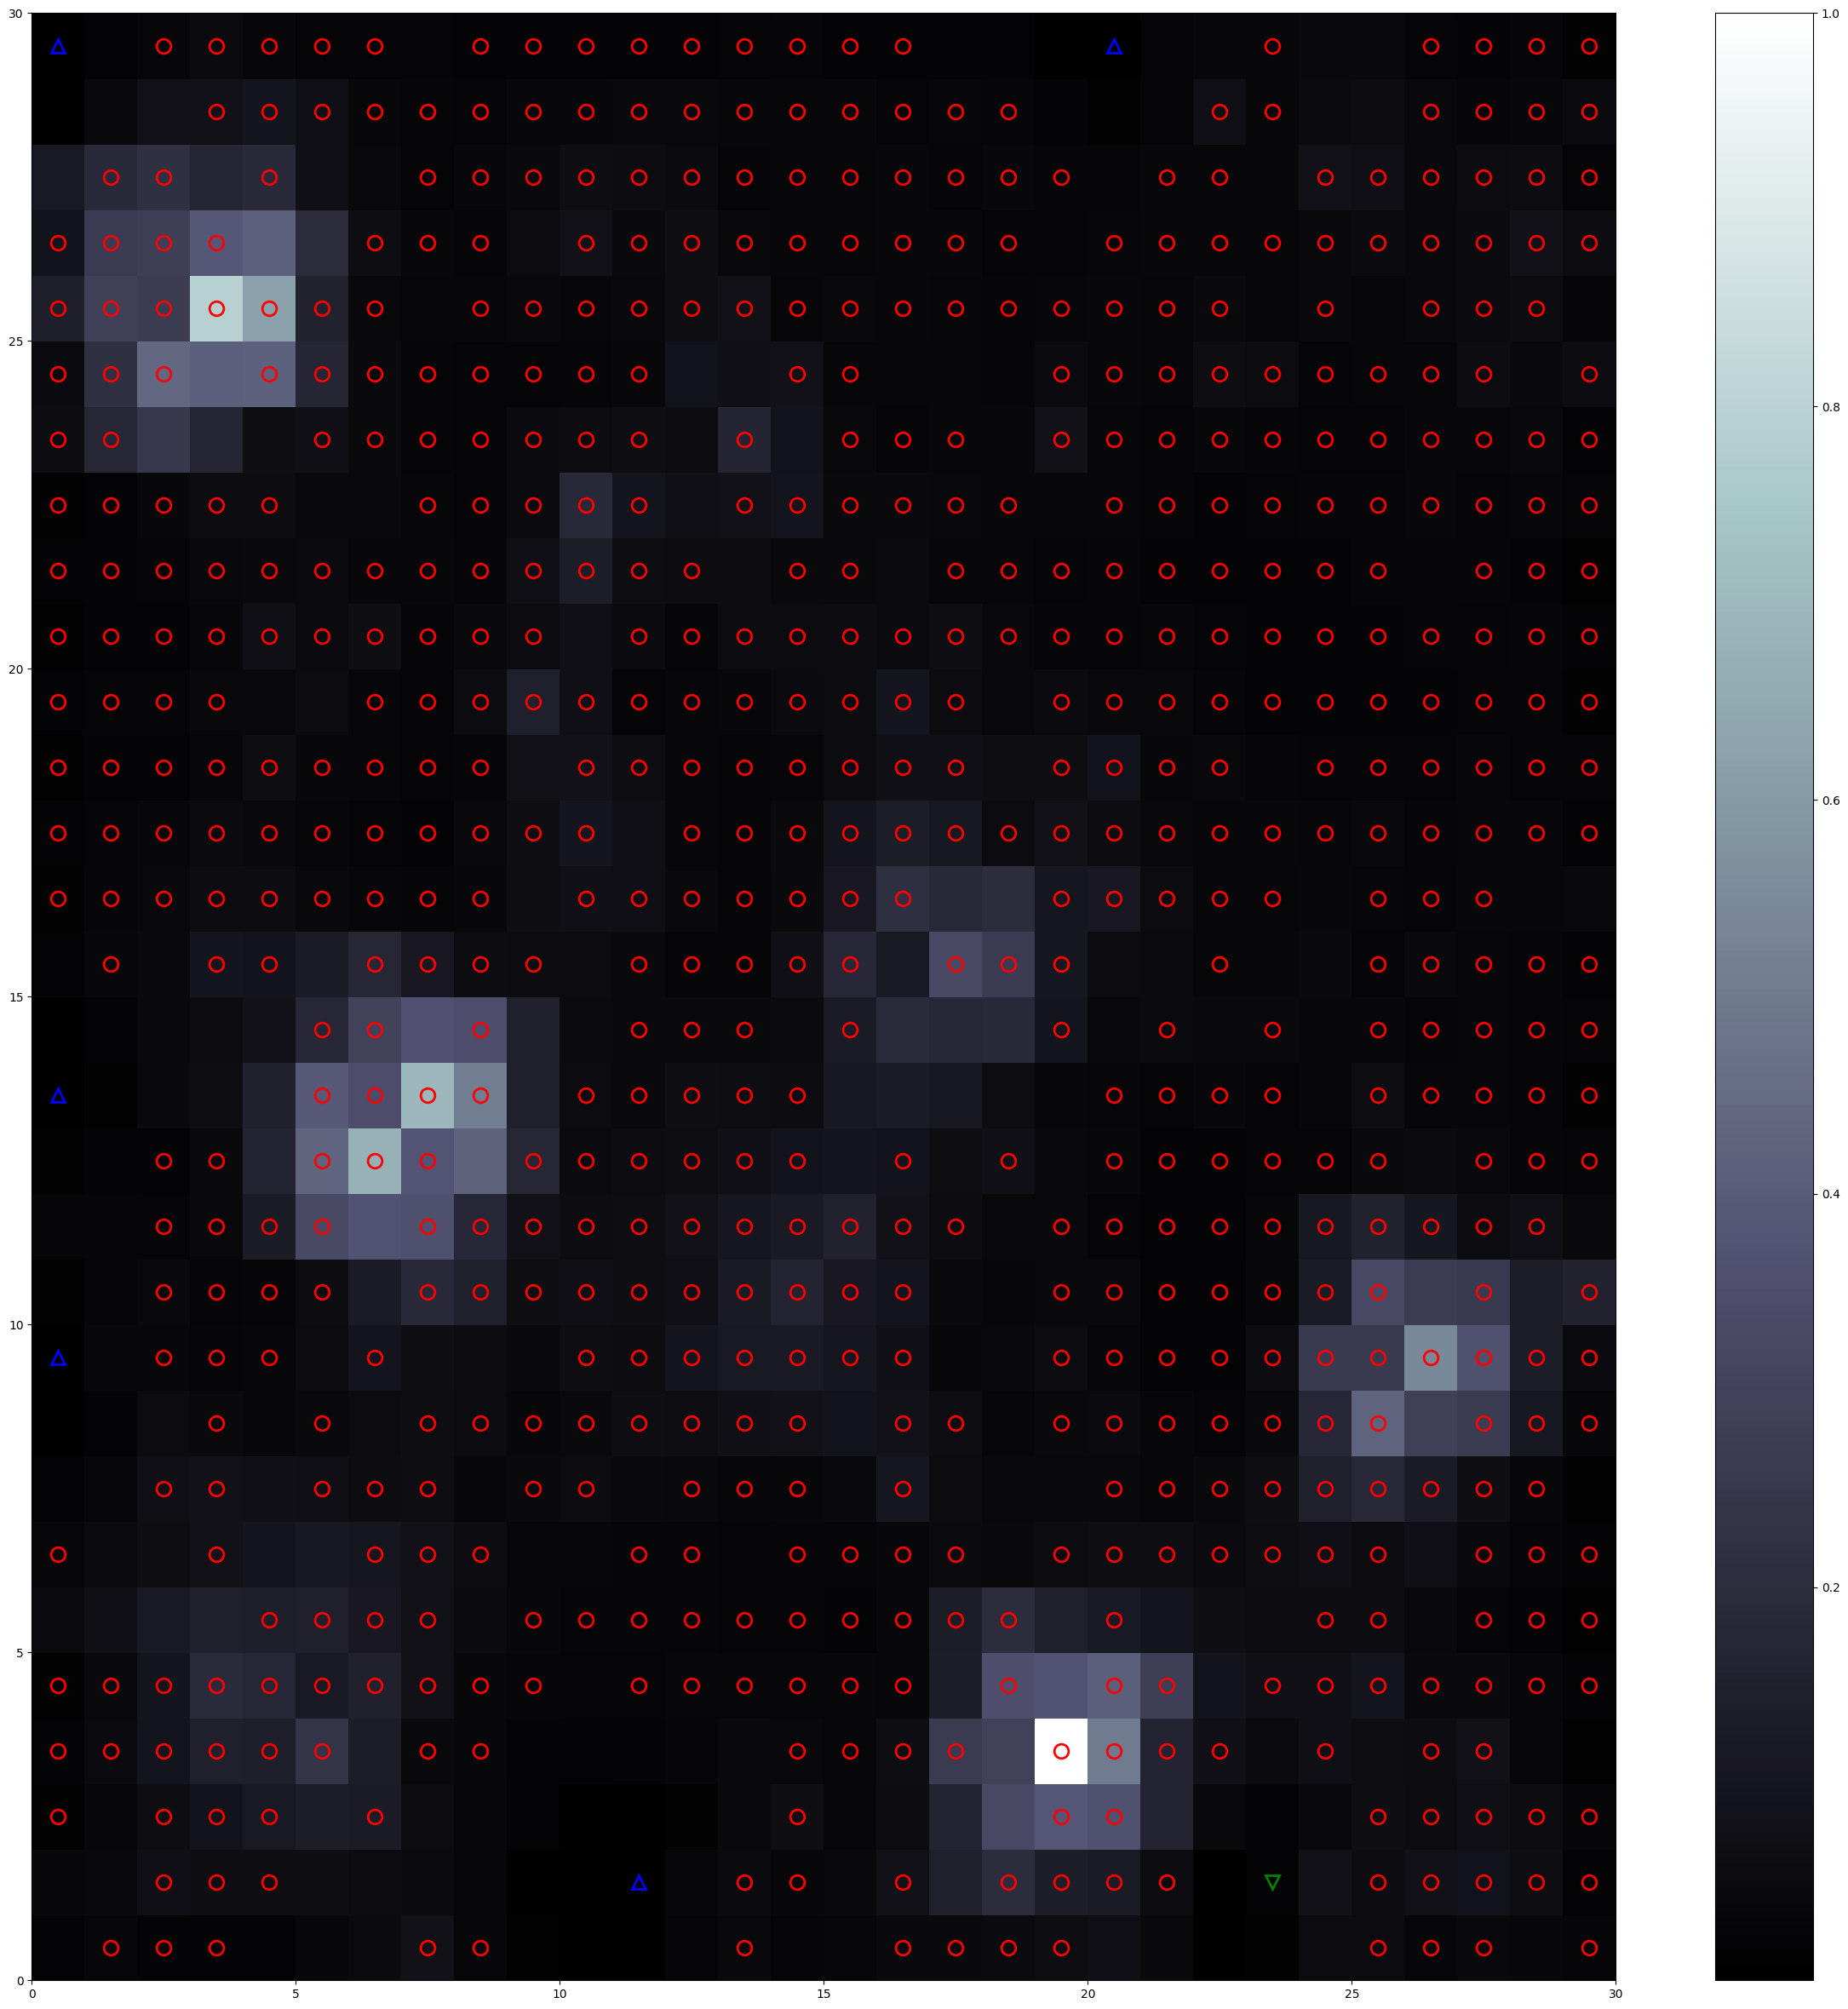

In [14]:
from pylab import bone, pcolor, colorbar, plot, show
from pylab import rcParams
from collections import defaultdict, Counter
import numpy as np

rcParams['figure.figsize'] = (d, d)

# ===== U-Matrix =====
bone()
pcolor(som.distance_map().T)
colorbar()

# ===== Etiquetado por mayoría =====
label_map = defaultdict(list)

for x, y in zip(x_train1d, y_train2d):
    label_map[som.winner(x)].append(y)

# ===== Visualización de muestras =====
markers = ['o', 'v', '^']
colors = ['r', 'g', 'b']

for pos, labels in label_map.items():
    clase = Counter(labels).most_common(1)[0][0]
    plot(
        pos[0] + 0.5,
        pos[1] + 0.5,
        markers[clase],
        markeredgecolor=colors[clase],
        markerfacecolor='None',
        markersize=12,
        markeredgewidth=2
    )

show()


Red SOM usando Hilos

In [ ]:
import os
import math
import threading
import numpy as np
from minisom import MiniSom
from collections import defaultdict, Counter
from sklearn.preprocessing import StandardScaler
from concurrent.futures import ThreadPoolExecutor

num_threads = os.cpu_count() or 1

# BMU (winner) con hilos
def winner_hilos(som: MiniSom, x: np.ndarray, num_threads: int = num_threads):
    """
    Retorna (i,j) BMU usando distancia euclídea, paralelizando por filas del mapa.
    """
    W = som._weights  # shape: (d, d, input_len)
    d1, d2, _ = W.shape

    # distancia euclídea al cuadrado: ||W[i,j,:] - x||^2
    # Para evitar crear un (d,d,input_len) gigante, calculamos por chunks de filas.
    best = {"dist": float("inf"), "pos": (0, 0)}
    lock = threading.Lock()

    # chunking por filas
    total_filas = d1
    filas_por_hilo = total_filas // num_threads
    if filas_por_hilo == 0:
        filas_por_hilo = 1

    def _chunk(x_start, x_end):
        local_best_dist = float("inf")
        local_best_pos = (0, 0)

        # Calcula distancias en [x_start:x_end, :, :]
        # diff = Wchunk - x -> sum(diff^2, axis=2)
        Wchunk = W[x_start:x_end, :, :]                    # (k, d2, input_len)
        diff = Wchunk - x.reshape(1, 1, -1)                # broadcast
        dist2 = np.sum(diff * diff, axis=2)                # (k, d2)

        idx = np.argmin(dist2)
        k, j = np.unravel_index(idx, dist2.shape)
        i = x_start + k
        local_best_dist = float(dist2[k, j])
        local_best_pos = (i, j)

        with lock:
            if local_best_dist < best["dist"]:
                best["dist"] = local_best_dist
                best["pos"] = local_best_pos

    threads = []
    x_inicio = 0
    for t in range(num_threads):
        x_fin = x_inicio + filas_por_hilo
        if t == num_threads - 1:
            x_fin = d1
        if x_inicio >= d1:
            break

        th = threading.Thread(target=_chunk, args=(x_inicio, min(x_fin, d1)))
        threads.append(th)
        th.start()
        x_inicio = x_fin

    for th in threads:
        th.join()

    return best["pos"]



# Entrenamiento train_random con hilos (BMU paralelo)
def train_random_hilos(som: MiniSom,
                       data: np.ndarray,
                       num_iteration: int,
                       seed: int = 42,
                       num_threads: int = num_threads):
  
    rng = np.random.RandomState(seed)
    n = data.shape[0]

    for t in range(num_iteration):
        x = data[rng.randint(n)]
        win = winner_hilos(som, x, num_threads=num_threads)
        som.update(x, win, t, num_iteration)


# Predicción en paralelo 
def predict_labels_hilos(som, X, M, clase_global, num_threads=num_threads):
    """
    Predice etiquetas para X usando BMU paralelo.
    """
    def _pred_one(x):
        pos = winner_hilos(som, x, num_threads=num_threads)
        lab = M[pos]
        return lab if lab != -1 else clase_global

    with ThreadPoolExecutor(max_workers=num_threads) as ex:
        y_pred = list(ex.map(_pred_one, X))

    return np.array(y_pred, dtype=int)


In [10]:
# Flatten
x_train1d = x_train2d.reshape(x_train2d.shape[0], -1)
x_test1d  = x_test2d.reshape(x_test2d.shape[0], -1)

# Normalización
scaler = StandardScaler()
x_train1d = scaler.fit_transform(x_train1d)
x_test1d  = scaler.transform(x_test1d)

max_iter = 4000
alpha_max = 0.5
dimension = np.array([10, 20, 30], dtype=int)

resultados = np.zeros(len(dimension), dtype=float)

print("CPU cores / hilos:", num_threads)

for j, d in enumerate(dimension):
    d = int(d)
    print(f"Entrenando SOM {d}x{d} con hilos")

    som = MiniSom(
        x=d, y=d,
        input_len=x_train1d.shape[1],
        sigma=1.0,
        learning_rate=alpha_max,
        activation_distance='euclidean',
        topology='hexagonal',
        neighborhood_function='gaussian',
        random_seed=42
    )

    som.random_weights_init(x_train1d)

    # >>> entrenamiento con hilos (BMU paralelo)
    train_random_hilos(som, x_train1d, num_iteration=max_iter, seed=42, num_threads=num_threads)

    # Etiquetado por mayoría usando BMU paralelo (opcional, pero consistente)
    label_map = defaultdict(list)
    for x, y in zip(x_train1d, y_train2d):
        pos = winner_hilos(som, x, num_threads=num_threads)
        label_map[pos].append(y)

    M = np.full((d, d), -1, dtype=int)
    for pos, labels in label_map.items():
        M[pos] = Counter(labels).most_common(1)[0][0]

    clase_global = Counter(y_train2d).most_common(1)[0][0]

    # Predicción en test (con hilos)
    y_pred = predict_labels_hilos(som, x_test1d, M, clase_global, num_threads=num_threads)

    resultados[j] = np.mean(y_pred == y_test2d)
    print(f"Accuracy SOM {d}x{d}: {resultados[j]:.4f}")

best_d = int(dimension[np.argmax(resultados)])
print("Mejor dimensión SOM:", best_d, "x", best_d)


CPU cores / hilos: 8
Entrenando SOM 10x10 con hilos
Accuracy SOM 10x10: 1.0000
Entrenando SOM 20x20 con hilos
Accuracy SOM 20x20: 1.0000
Entrenando SOM 30x30 con hilos
Accuracy SOM 30x30: 1.0000
Mejor dimensión SOM: 10 x 10


In [11]:
from concurrent.futures import ThreadPoolExecutor
import numpy as np

def som_predict(X, som, M, clase_global, num_threads):
    """
    Predicción de etiquetas usando SOM con BMU paralelo.
    """
    def _predict_one(x):
        pos = winner_hilos(som, x, num_threads=num_threads)
        lab = M[pos]
        return lab if lab != -1 else clase_global

    with ThreadPoolExecutor(max_workers=num_threads) as ex:
        y_pred = list(ex.map(_predict_one, X))

    return np.array(y_pred, dtype=int)


Evaluacion del Entrenamiento

In [12]:
from sklearn.metrics import confusion_matrix, classification_report

print("\n=== EVALUACIÓN EN TRAIN (datos vistos) ===")

y_pred_train = som_predict(
    x_train1d,
    som,
    M,
    clase_global,
    num_threads=num_threads
)

print(confusion_matrix(y_train2d, y_pred_train))
print(classification_report(y_train2d, y_pred_train))



=== EVALUACIÓN EN TRAIN (datos vistos) ===
[[3925    0    0]
 [   0  391    0]
 [   0    0 2024]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3925
           1       1.00      1.00      1.00       391
           2       1.00      1.00      1.00      2024

    accuracy                           1.00      6340
   macro avg       1.00      1.00      1.00      6340
weighted avg       1.00      1.00      1.00      6340



Evaluacion de datos test

In [15]:
print("\n=== EVALUACIÓN EN TEST (datos no vistos) ===")

y_pred_test = som_predict(
    x_test1d,
    som,
    M,
    clase_global,
    num_threads=num_threads
)

print(confusion_matrix(y_test2d, y_pred_test))
print(classification_report(y_test2d, y_pred_test))


=== EVALUACIÓN EN TEST (datos no vistos) ===
[[995   0   0]
 [  0 110   0]
 [  0   0 481]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       995
           1       1.00      1.00      1.00       110
           2       1.00      1.00      1.00       481

    accuracy                           1.00      1586
   macro avg       1.00      1.00      1.00      1586
weighted avg       1.00      1.00      1.00      1586



Mostrando la agrupación de la matriz de índice.

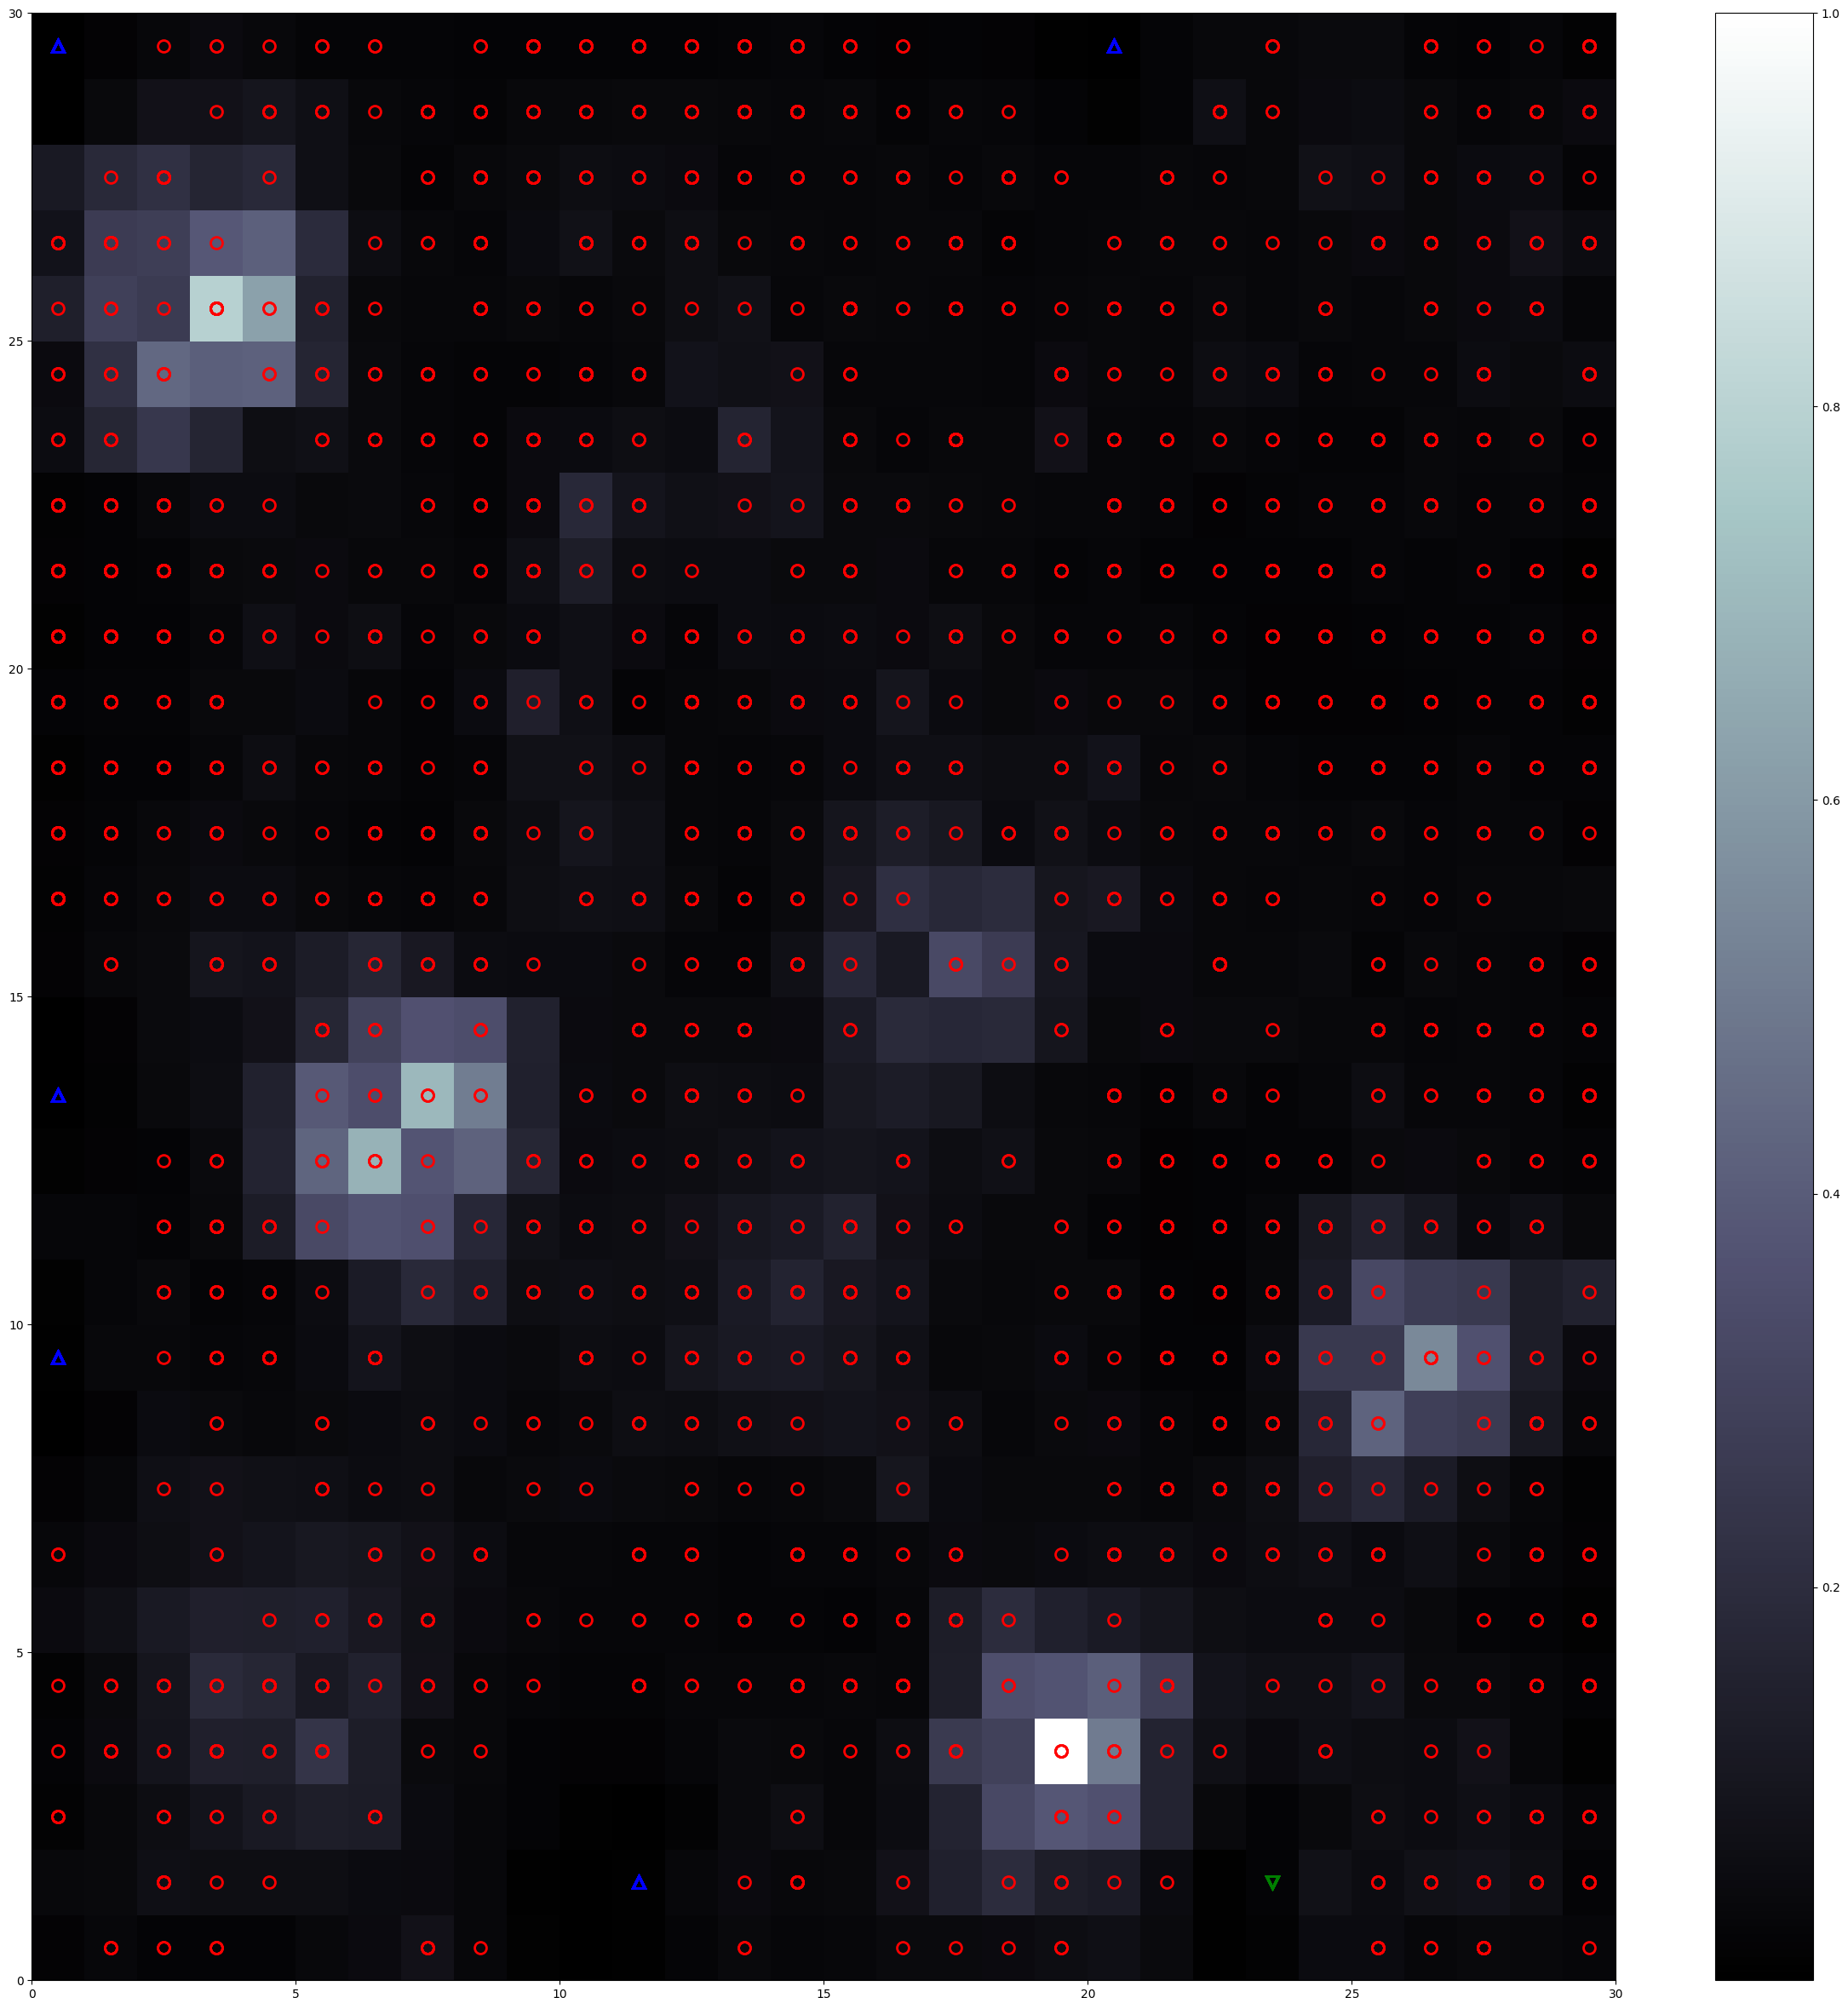

In [13]:
from pylab import bone, pcolor, colorbar, plot, show, rcParams
import numpy as np
from collections import defaultdict, Counter

# ===============================
# Configuración de figura
# ===============================
rcParams['figure.figsize'] = (d, d)

# ===============================
# U-Matrix
# ===============================
bone()
pcolor(som.distance_map().T)
colorbar()

# ===============================
# Visualización de clases (BMU con hilos)
# ===============================
markers = ['o', 'v', '^']      # ajusta si tienes más clases
colors  = ['r', 'g', 'b']

# (opcional) matriz de etiquetas finales para inspección
M_vis = np.full((d, d), -1, dtype=int)

for i, x in enumerate(x_train1d):
    # BMU usando hilos
    w = winner_hilos(som, x, num_threads=num_threads)

    clase = int(y_train2d[i])

    plot(
        w[0] + 0.5,
        w[1] + 0.5,
        markers[clase],
        markeredgecolor=colors[clase],
        markerfacecolor='None',
        markersize=10,
        markeredgewidth=2
    )

    M_vis[w[0], w[1]] = clase

show()
